--- 1. ДОСЛІДНИЦЬКИЙ АНАЛІЗ ДАНИХ (EDA) ---
--- Основні цифри (Середне, Медіана, Квартилі) ---
count    8760.000000
mean       80.441192
std        25.686709
min        37.819000
25%        58.404750
50%        78.603500
75%        98.753250
max       140.090000
Name: value, dtype: float64

--- Перевірка на пропуски (має бути 0) ---
meter_id      0
ts            0
value         0
temp          0
irrad         0
hour          0
day_name      0
month         0
is_weekend    0
dtype: int64


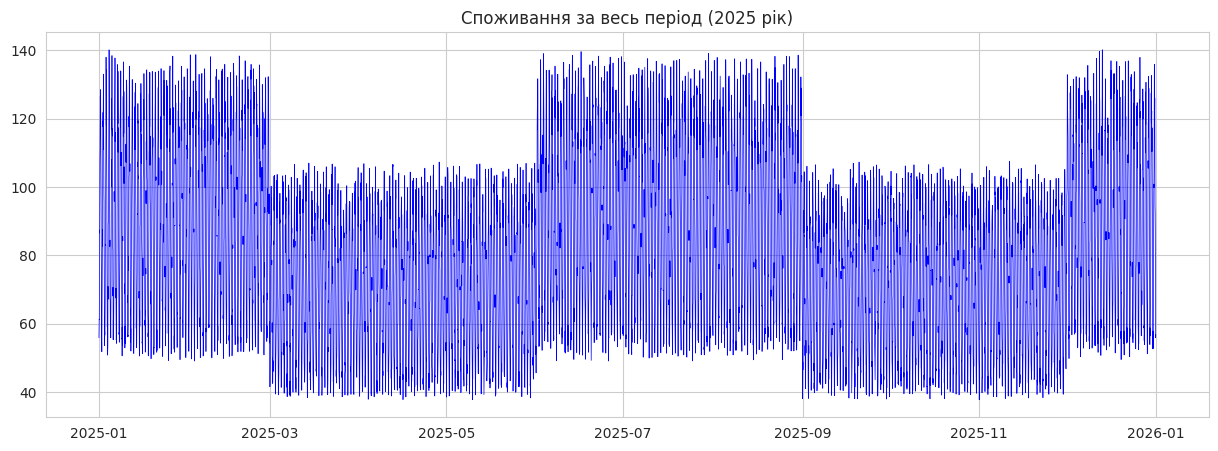

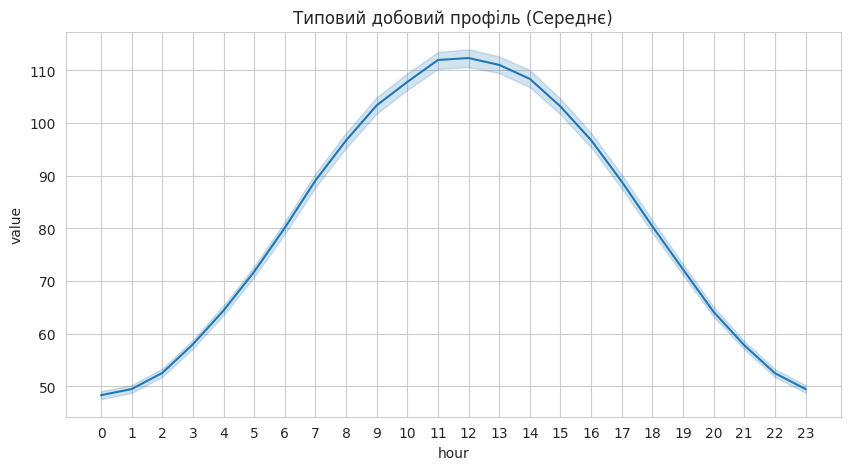

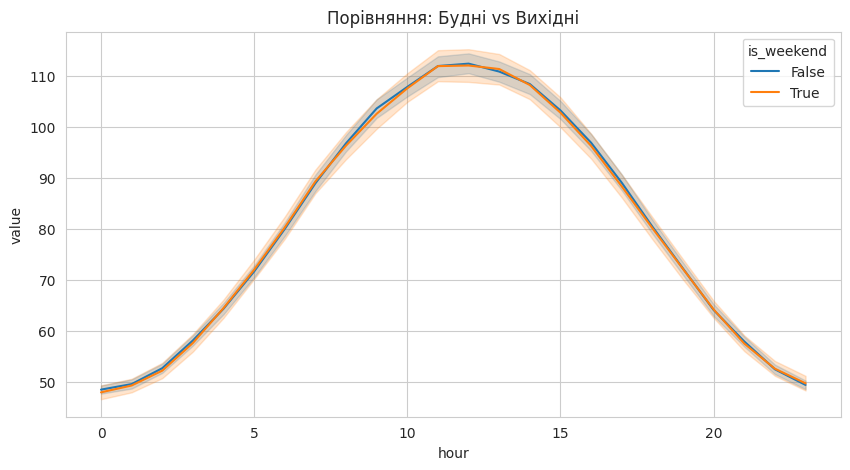

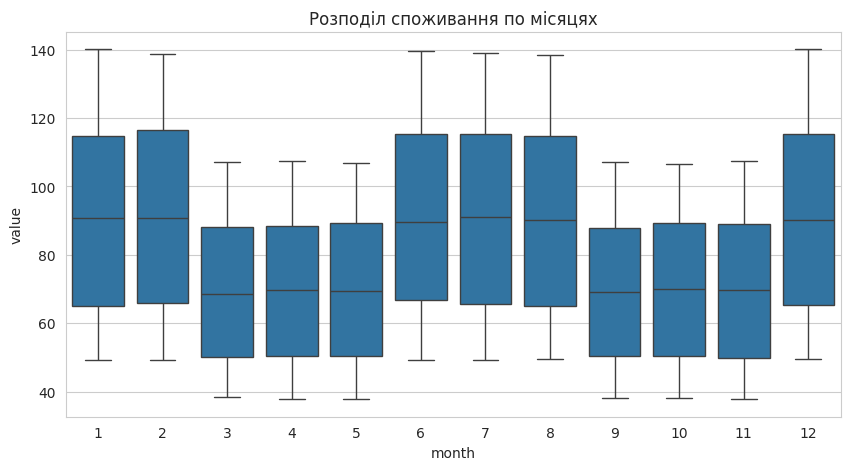

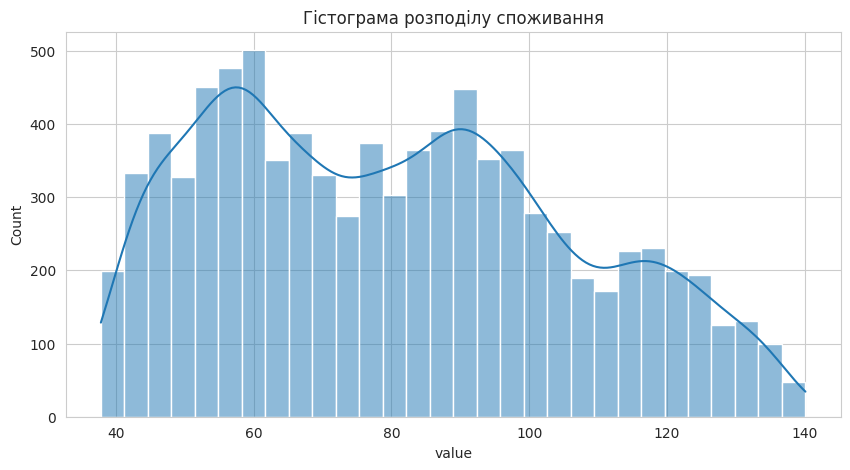

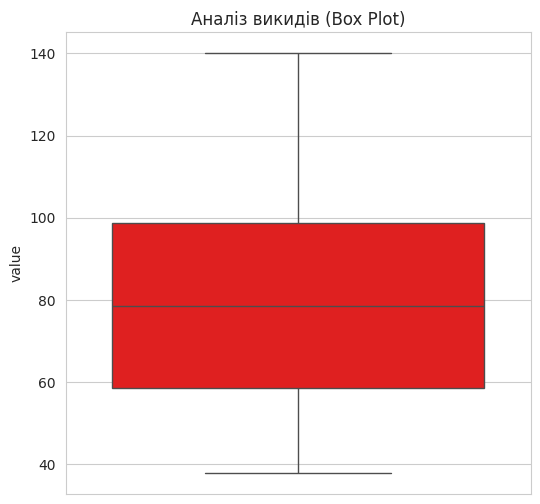

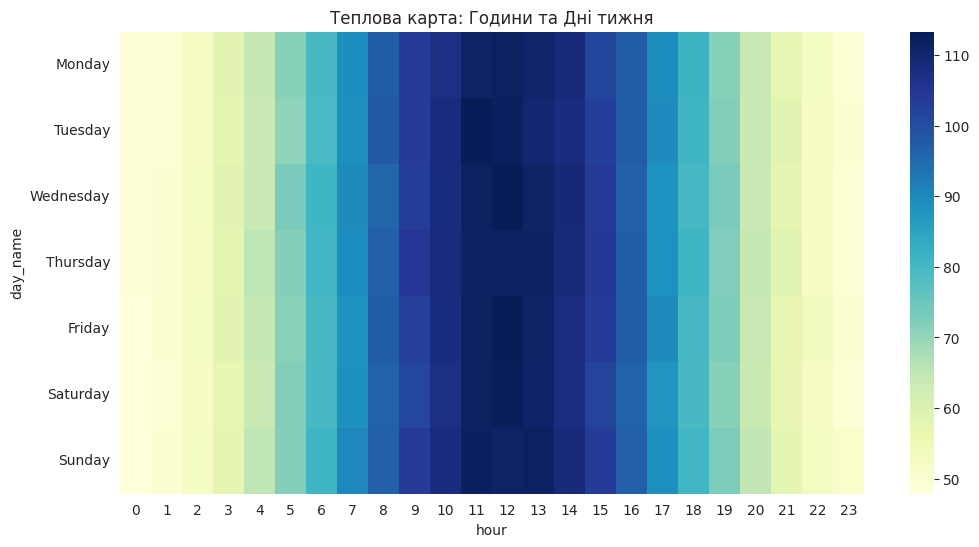

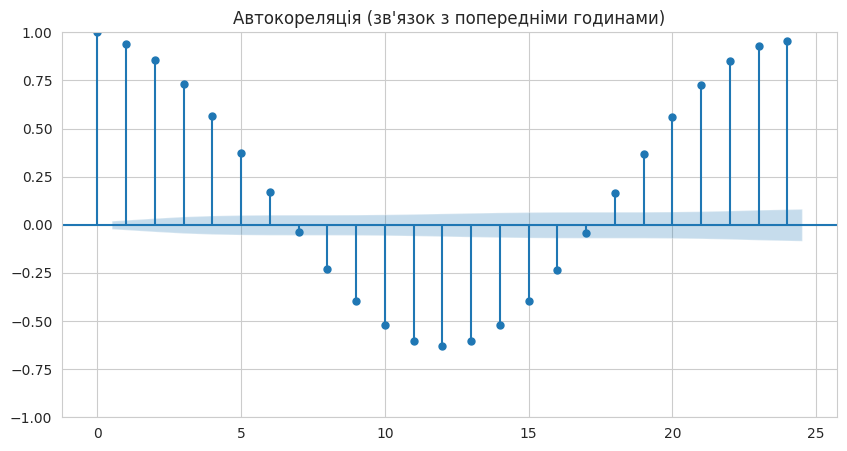

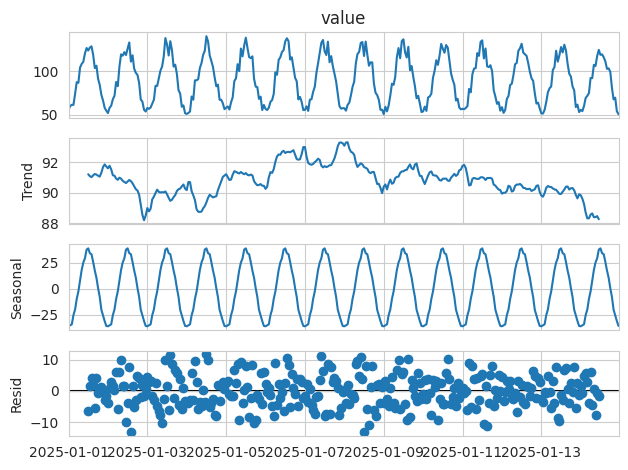


--- 2. ФАКТОРНИЙ АНАЛІЗ ---
--- Матриця кореляції (вплив на 'value') ---
value    1.000000
irrad    0.791544
CDD      0.025589
temp     0.005442
HDD     -0.001100
Name: value, dtype: float64


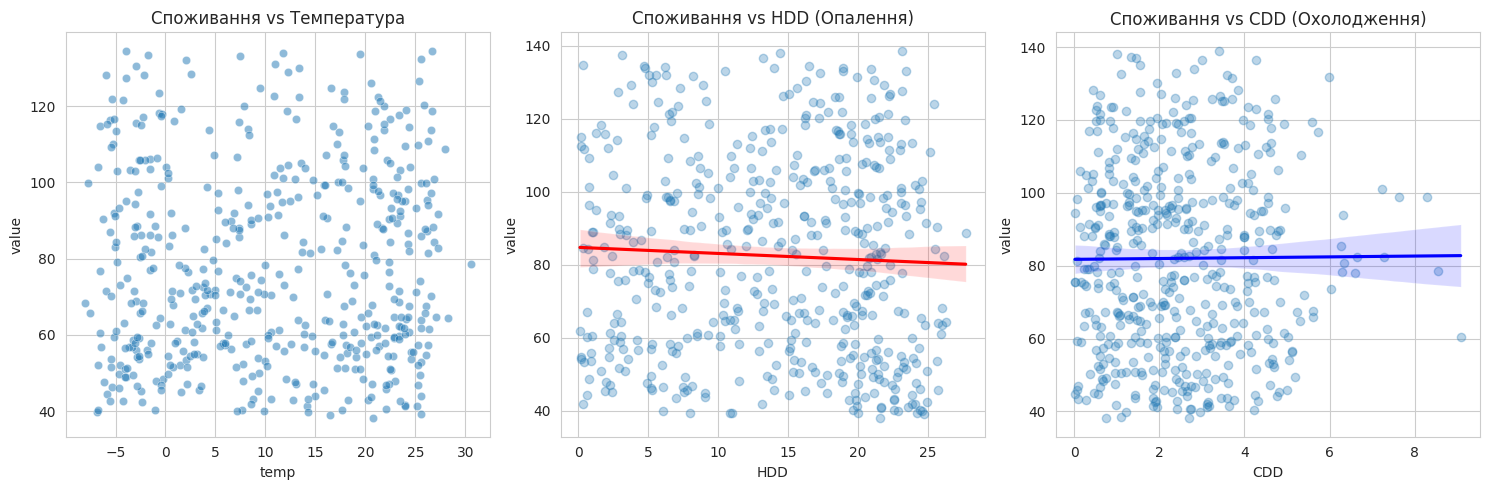


--- 3. ПОБУДОВА МОДЕЛЕЙ ---
Linear Regression R2: 0.9556
Random Forest R2: 0.9593


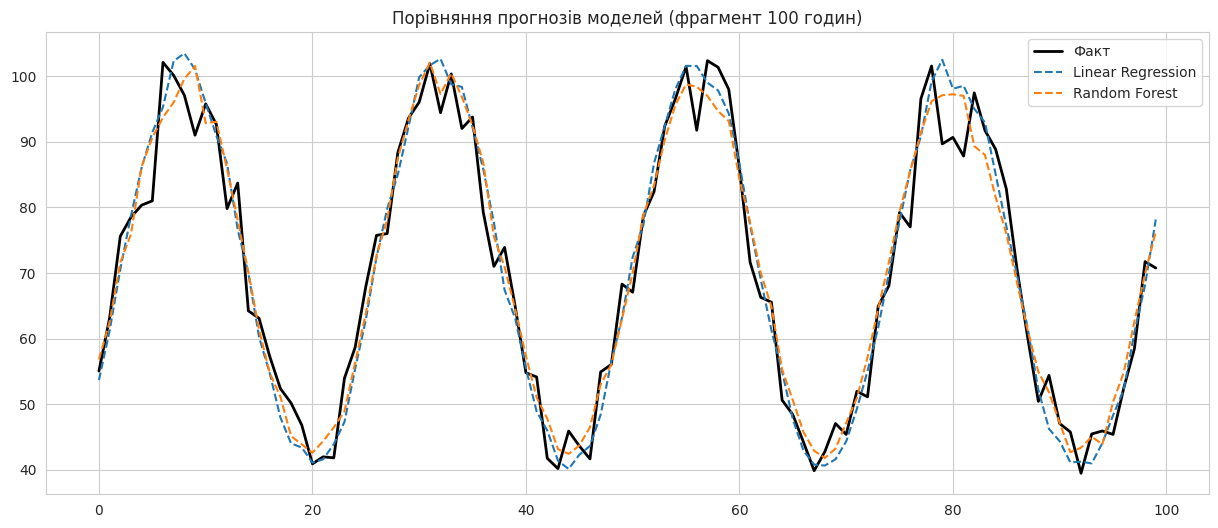


--- 4. ОЦІНКА ТА ПРОГНОЗУВАННЯ ---
--- Порівняльна таблиця моделей ---
              Модель        R2      RMSE       MAE  MAPE (%)
0  Linear Regression  0.955595  5.261602  4.231632  5.466570
1      Random Forest  0.959265  5.039471  3.979800  5.073714


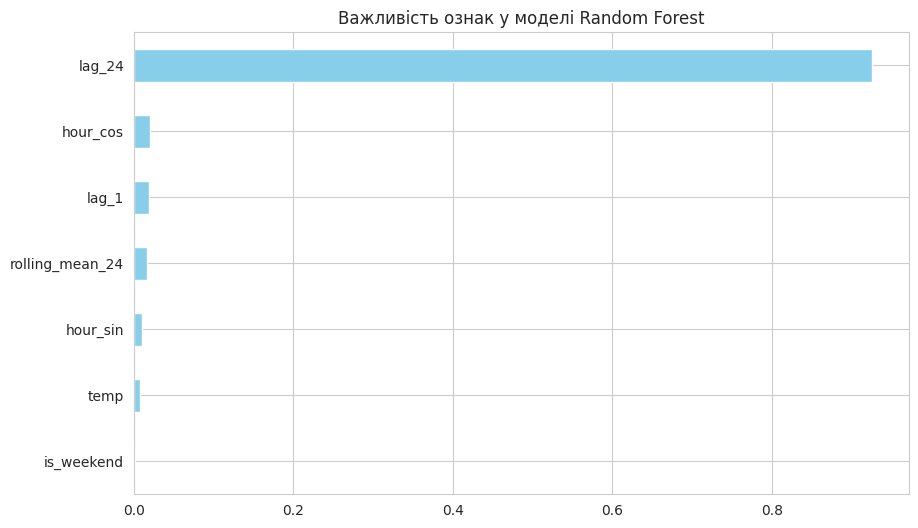


--- Прогноз на наступний місяць ---
Очікуване споживання: 56739.85 кВт·год
Очікувана вартість: 368809.01 грн


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

df_readings = pd.read_csv('/kaggle/input/datasets/vovan4oman/readings/readings.csv', parse_dates=['ts'])
df_weather = pd.read_csv('/kaggle/input/datasets/vovan4oman/weather/weather.csv', parse_dates=['ts'])

df = df_readings[df_readings['meter_id'] == 1].merge(df_weather, on='ts')

df['hour'] = df['ts'].dt.hour
df['day_name'] = df['ts'].dt.day_name()
df['month'] = df['ts'].dt.month
df['is_weekend'] = df['ts'].dt.dayofweek.isin([5, 6])

print("--- 1. ДОСЛІДНИЦЬКИЙ АНАЛІЗ ДАНИХ (EDA) ---")
print("--- Основні цифри (Середне, Медіана, Квартилі) ---")
print(df['value'].describe())

print("\n--- Перевірка на пропуски (має бути 0) ---")
print(df.isnull().sum())

sns.set_style("whitegrid")

plt.figure(figsize=(15, 5))
plt.plot(df['ts'], df['value'], color='blue', linewidth=0.5)
plt.title('Споживання за весь період (2025 рік)')
plt.show()

plt.figure(figsize=(10, 5))
sns.lineplot(data=df, x='hour', y='value')
plt.title('Типовий добовий профіль (Середнє)')
plt.xticks(range(0, 24))
plt.show()

plt.figure(figsize=(10, 5))
sns.lineplot(data=df, x='hour', y='value', hue='is_weekend')
plt.title('Порівняння: Будні vs Вихідні')
plt.show()

plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='month', y='value')
plt.title('Розподіл споживання по місяцях')
plt.show()

plt.figure(figsize=(10, 5))
sns.histplot(df['value'], bins=30, kde=True)
plt.title('Гістограма розподілу споживання')
plt.show()

plt.figure(figsize=(6, 6))
sns.boxplot(y=df['value'], color='red')
plt.title('Аналіз викидів (Box Plot)')
plt.show()

pivot = df.pivot_table(index='day_name', columns='hour', values='value', aggfunc='mean')
days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
pivot = pivot.reindex(days)

plt.figure(figsize=(12, 6))
sns.heatmap(pivot, cmap='YlGnBu')
plt.title('Теплова карта: Години та Дні тижня')
plt.show()

plt.figure(figsize=(10, 5))
plot_acf(df['value'], lags=24, ax=plt.gca())
plt.title('Автокореляція (зв\'язок з попередніми годинами)')
plt.show()

df_small = df.iloc[:24*14].set_index('ts') 
decomp = seasonal_decompose(df_small['value'], model='additive', period=24)
decomp.plot()
plt.show()

print("\n--- 2. ФАКТОРНИЙ АНАЛІЗ ---")
df['HDD'] = df['temp'].apply(lambda x: max(0, 18 - x))
df['CDD'] = df['temp'].apply(lambda x: max(0, x - 22))

corr_matrix = df[['value', 'temp', 'HDD', 'CDD', 'irrad']].corr()
print("--- Матриця кореляції (вплив на 'value') ---")
print(corr_matrix['value'].sort_values(ascending=False))

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
sns.scatterplot(data=df.sample(500), x='temp', y='value', alpha=0.5)
plt.title('Споживання vs Температура')

plt.subplot(1, 3, 2)
sns.regplot(data=df[df['HDD'] > 0].sample(500), x='HDD', y='value', scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Споживання vs HDD (Опалення)')

plt.subplot(1, 3, 3)
sns.regplot(data=df[df['CDD'] > 0].sample(500), x='CDD', y='value', scatter_kws={'alpha':0.3}, line_kws={'color':'blue'})
plt.title('Споживання vs CDD (Охолодження)')
plt.tight_layout()
plt.show()

print("\n--- 3. ПОБУДОВА МОДЕЛЕЙ ---")
df['lag_1'] = df['value'].shift(1)
df['lag_24'] = df['value'].shift(24)
df['rolling_mean_24'] = df['value'].rolling(window=24).mean()
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 23)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 23)

df_ml = df.dropna()
features = ['hour_sin', 'hour_cos', 'temp', 'is_weekend', 'lag_1', 'lag_24', 'rolling_mean_24']
X = df_ml[features]
y = df_ml['value']

train_size = int(len(df_ml) * 0.8)
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print(f"Linear Regression R2: {r2_score(y_test, y_pred_lr):.4f}")
print(f"Random Forest R2: {r2_score(y_test, y_pred_rf):.4f}")

plt.figure(figsize=(15, 6))
plt.plot(y_test.values[:100], label='Факт', color='black', linewidth=2)
plt.plot(y_pred_lr[:100], label='Linear Regression', linestyle='--')
plt.plot(y_pred_rf[:100], label='Random Forest', linestyle='--')
plt.title('Порівняння прогнозів моделей (фрагмент 100 годин)')
plt.legend()
plt.show()

print("\n--- 4. ОЦІНКА ТА ПРОГНОЗУВАННЯ ---")
def get_metrics(y_true, y_pred, name):
    return {
        'Модель': name,
        'R2': r2_score(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAE': mean_absolute_error(y_true, y_pred),
        'MAPE (%)': mean_absolute_percentage_error(y_true, y_pred) * 100
    }

metrics_df = pd.DataFrame([
    get_metrics(y_test, y_pred_lr, 'Linear Regression'),
    get_metrics(y_test, y_pred_rf, 'Random Forest')
])

print("--- Порівняльна таблиця моделей ---")
print(metrics_df)

importances = pd.Series(rf_model.feature_importances_, index=features).sort_values(ascending=True)
plt.figure(figsize=(10, 6))
importances.plot(kind='barh', color='skyblue')
plt.title('Важливість ознак у моделі Random Forest')
plt.show()

avg_daily_cons = y_pred_rf.mean() * 24
monthly_cons = avg_daily_cons * 30
expected_cost = monthly_cons * 6.5 

print(f"\n--- Прогноз на наступний місяць ---")
print(f"Очікуване споживання: {monthly_cons:.2f} кВт·год")
print(f"Очікувана вартість: {expected_cost:.2f} грн")

Моделі компонентів для Готелю №4 створено успішно.
Симуляція алгоритму управління завершена.


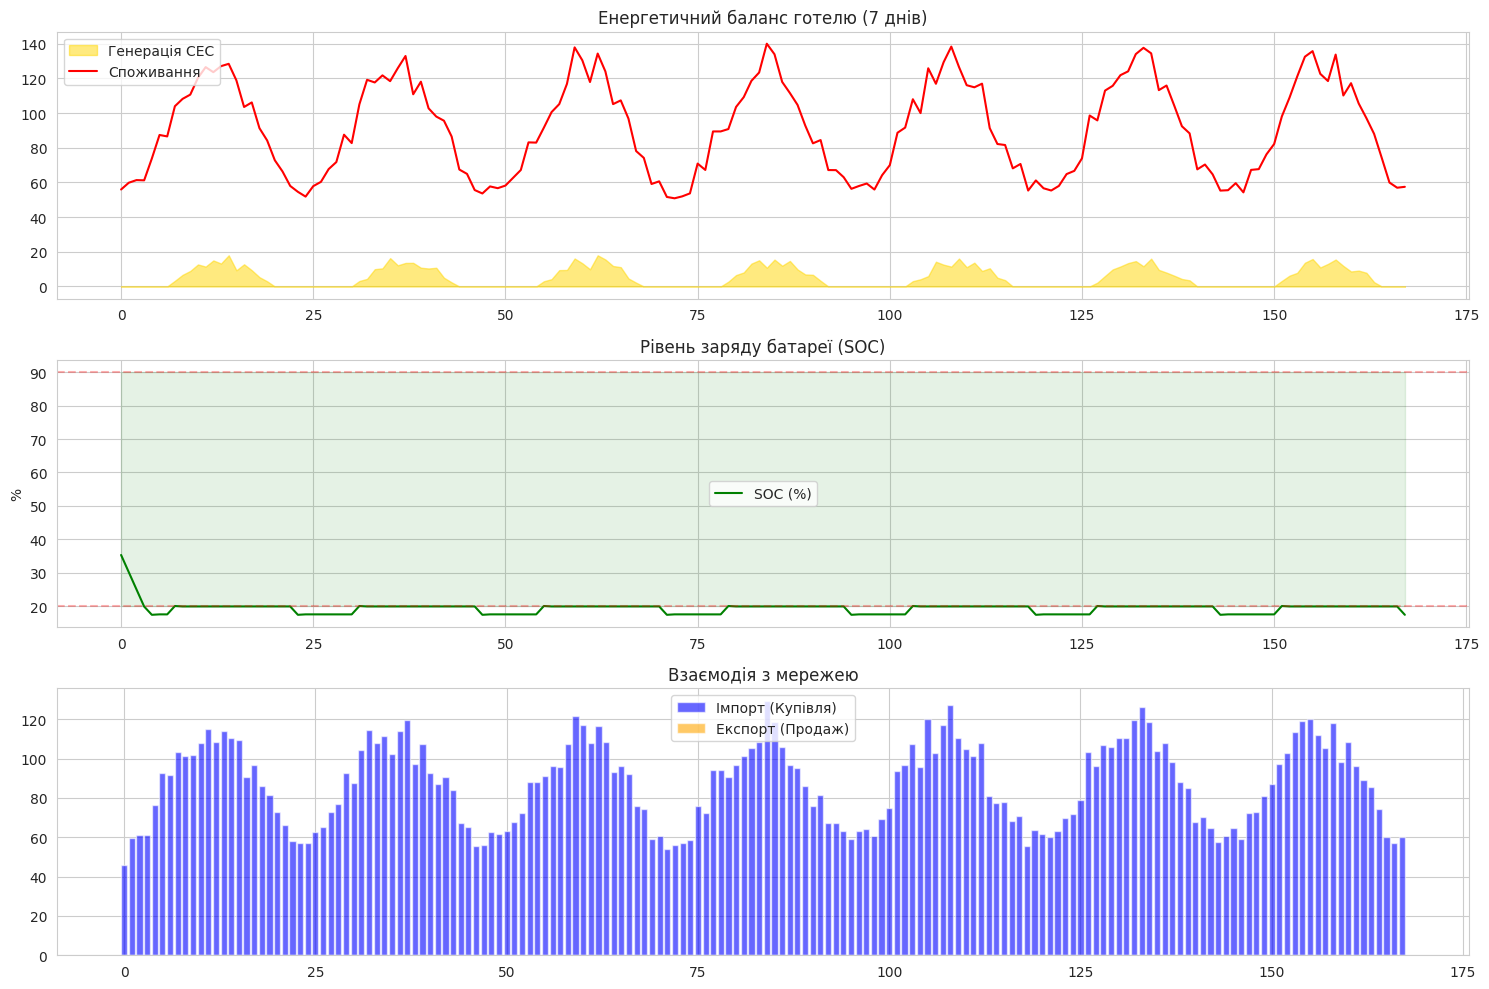

Загальна вартість енергії за тиждень: 95987.93 грн
--- ЕНЕРГЕТИЧНІ ПОКАЗНИКИ ---
Покриття споживання за рахунок СЕС: 4.12 %
Рівень самоспоживання СЕС: 100.00 %

--- ЕКОНОМІЧНІ ПОКАЗНИКИ ---
Базова вартість (без системи): 100622.51 грн
Фактична вартість (з EMS): 95987.93 грн
Економія за тиждень: 4634.58 грн
Прогнозована економія на рік: 240997.90 грн
Термін окупності системи: 19.05 років


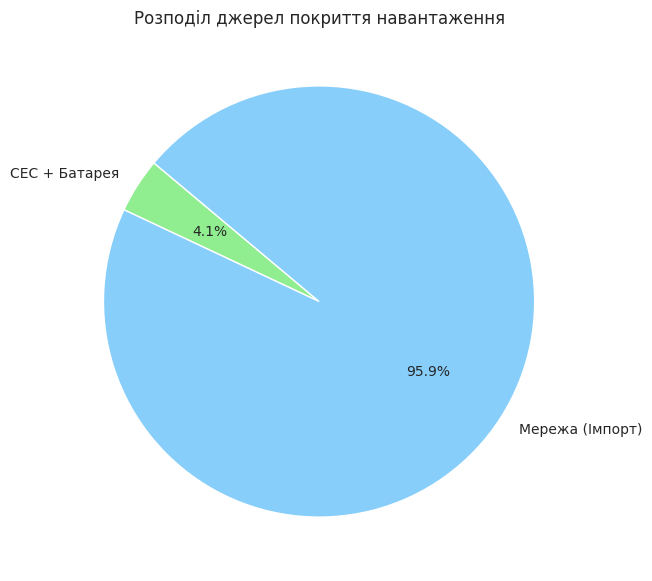

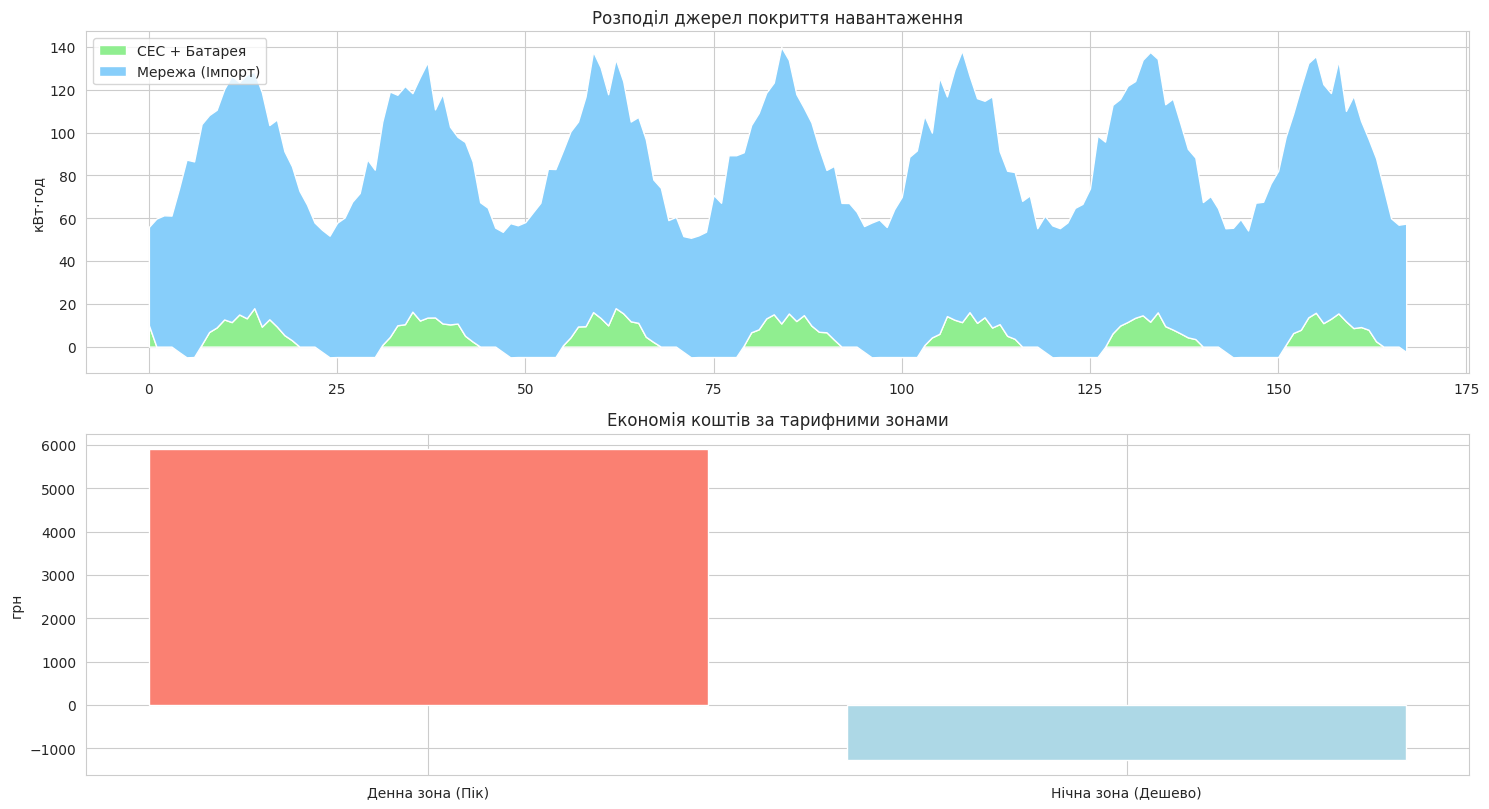

--- РЕЗУЛЬТАТИ СИМУЛЯЦІЇ (ПЕРША ДОБА) ---
          Timestamp  Generation  Consumption       SOC     Import  Export       Cost
2025-01-01 00:00:00    0.000000       55.958 35.364884  45.958000       0 257.364800
2025-01-01 01:00:00    0.000000       59.848 30.230282  59.848000       0 335.148800
2025-01-01 02:00:00    0.000000       61.373 25.096193  61.373000       0 343.688800
2025-01-01 03:00:00    0.000000       61.238 19.962618  61.238000       0 342.932800
2025-01-01 04:00:00    0.000000       73.808 17.500217  76.345382       0 427.534141
2025-01-01 05:00:00    0.000000       87.408 17.629804  92.407783       0 517.483583
2025-01-01 06:00:00    0.000000       86.574 17.622985  91.444196       0 512.087496
2025-01-01 07:00:00    3.260074      104.001 20.123094 103.117941       0 711.513792
2025-01-01 08:00:00    6.699701      108.230 19.991522 101.407205       0 699.709716
2025-01-01 09:00:00    8.960902      110.691 19.998446 101.738576       0 701.996177
2025-01-01 10:00:00   1

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

class SolarPlant:
    def __init__(self, capacity_kw=120):
        self.capacity = capacity_kw
        self.efficiency = 0.18
        self.degradation = 0.005
        self.temp_coeff = -0.004

    def get_generation(self, irrad, temp):
        base_gen = (irrad / 1000) * self.capacity * self.efficiency
        temp_correction = 1 + (temp - 25) * self.temp_coeff
        return max(0, base_gen * temp_correction * (1 - self.degradation))

class BatteryStorage:
    def __init__(self, capacity_kwh=100):
        self.capacity = capacity_kwh
        self.soc = 50.0
        self.min_soc = 20.0
        self.max_soc = 90.0
        self.max_power = 50.0
        self.efficiency = 0.95
        self.self_discharge = 0.0001

    def charge(self, power_kw):
        actual_power = min(power_kw, self.max_power)
        can_accept = (self.max_soc - self.soc) * self.capacity / 100
        power_to_add = min(actual_power, can_accept)
        self.soc += (power_to_add * self.efficiency) / self.capacity * 100
        return power_to_add

    def discharge(self, power_kw):
        actual_power = min(power_kw, self.max_power)
        can_give = (self.soc - self.min_soc) * self.capacity / 100
        power_to_take = min(actual_power, can_give)
        self.soc -= (power_to_take / self.efficiency) / self.capacity * 100
        return power_to_take

    def apply_self_discharge(self):
        self.soc *= (1 - self.self_discharge)

class PowerGrid:
    def __init__(self):
        self.max_limit = 300
        self.green_tariff = 6.5

    def get_tariff(self, ts):
        hour = ts.hour
        if 7 <= hour < 23:
            return 6.9
        else:
            return 5.6

class BuildingLoad:
    def __init__(self, data_series):
        self.data = data_series
    
    def get_load(self, step):
        return self.data.iloc[step]

solar = SolarPlant(capacity_kw=120)
battery = BatteryStorage(capacity_kwh=100)
grid = PowerGrid()
load = BuildingLoad(df['value'])

print("Моделі компонентів для Готелю №4 створено успішно.")

results = []
for i in range(len(df)):
    row = df.iloc[i]
    ts = row['ts']
    p_sun = solar.get_generation(row['irrad'], row['temp'])
    p_load = load.get_load(i)
    current_tariff = grid.get_tariff(ts)
    net_balance = p_sun - p_load
    p_grid_import = 0
    p_grid_export = 0
    
    if current_tariff == 5.6:
        battery.charge(battery.max_power)
    
    if net_balance > 0:
        charged = battery.charge(net_balance)
        p_grid_export = net_balance - charged
    else:
        needed = abs(net_balance)
        discharged = battery.discharge(needed)
        p_grid_import = needed - discharged

    battery.apply_self_discharge()
    results.append({
        'ts': ts,
        'p_sun': p_sun,
        'p_load': p_load,
        'soc': battery.soc,
        'grid_import': p_grid_import,
        'grid_export': p_grid_export,
        'cost': p_grid_import * current_tariff - p_grid_export * grid.green_tariff
    })

df_res = pd.DataFrame(results)
print("Симуляція алгоритму управління завершена.")

df_week = df.iloc[:168].copy()
battery.soc = 50.0
week_results = []

for i in range(len(df_week)):
    row = df_week.iloc[i]
    ts = row['ts']
    p_sun = solar.get_generation(row['irrad'], row['temp'])
    p_load = load.get_load(i)
    current_tariff = grid.get_tariff(ts)
    
    p_grid_charge = 0
    if current_tariff == 5.6:
        p_grid_charge = battery.charge(battery.max_power)
    
    net_balance = p_sun - p_load
    p_import = p_grid_charge
    p_export = 0
    
    if net_balance > 0:
        charged = battery.charge(net_balance)
        p_export = net_balance - charged
    else:
        needed = abs(net_balance)
        discharged = battery.discharge(needed)
        p_import += (needed - discharged)
    
    battery.apply_self_discharge()
    week_results.append({
        'Hour': i,
        'Timestamp': ts,
        'Generation': p_sun,
        'Consumption': p_load,
        'SOC': battery.soc,
        'Import': p_import,
        'Export': p_export,
        'Cost': (p_import * current_tariff) - (p_export * grid.green_tariff)
    })

df_sim = pd.DataFrame(week_results)

plt.figure(figsize=(15, 10))
plt.subplot(3, 1, 1)
plt.fill_between(df_sim['Hour'], df_sim['Generation'], label='Генерація СЕС', color='gold', alpha=0.5)
plt.plot(df_sim['Hour'], df_sim['Consumption'], label='Споживання', color='red', linewidth=1.5)
plt.title('Енергетичний баланс готелю (7 днів)')
plt.legend()

plt.subplot(3, 1, 2)
plt.plot(df_sim['Hour'], df_sim['SOC'], color='green', label='SOC (%)')
plt.axhline(y=90, color='r', linestyle='--', alpha=0.3)
plt.axhline(y=20, color='r', linestyle='--', alpha=0.3)
plt.fill_between(df_sim['Hour'], 20, 90, color='green', alpha=0.1)
plt.title('Рівень заряду батареї (SOC)')
plt.ylabel('%')
plt.legend()

plt.subplot(3, 1, 3)
plt.bar(df_sim['Hour'], df_sim['Import'], label='Імпорт (Купівля)', color='blue', alpha=0.6)
plt.bar(df_sim['Hour'], -df_sim['Export'], label='Експорт (Продаж)', color='orange', alpha=0.6)
plt.title('Взаємодія з мережею')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Загальна вартість енергії за тиждень: {df_sim['Cost'].sum():.2f} грн")

total_gen = df_sim['Generation'].sum()
total_load = df_sim['Consumption'].sum()
total_export = df_sim['Export'].sum()
pv_coverage = (1 - df_sim['Import'].sum() / total_load) * 100
self_consumption = ((total_gen - total_export) / total_gen) * 100

base_cost = 0
for i in range(len(df_week)):
    base_cost += df_week.iloc[i]['value'] * grid.get_tariff(df_week.iloc[i]['ts'])

actual_cost = df_sim['Cost'].sum()
savings_week = base_cost - actual_cost
savings_year = savings_week * 52
capex_usd = (120 * 600) + (100 * 400) 
capex_uah = capex_usd * 41
payback_period = capex_uah / savings_year

print(f"--- ЕНЕРГЕТИЧНІ ПОКАЗНИКИ ---")
print(f"Покриття споживання за рахунок СЕС: {pv_coverage:.2f} %")
print(f"Рівень самоспоживання СЕС: {self_consumption:.2f} %")
print(f"\n--- ЕКОНОМІЧНІ ПОКАЗНИКИ ---")
print(f"Базова вартість (без системи): {base_cost:.2f} грн")
print(f"Фактична вартість (з EMS): {actual_cost:.2f} грн")
print(f"Економія за тиждень: {savings_week:.2f} грн")
print(f"Прогнозована економія на рік: {savings_year:.2f} грн")
print(f"Термін окупності системи: {payback_period:.2f} років")

labels = ['СЕС + Батарея', 'Мережа (Імпорт)']
sizes = [total_load - df_sim['Import'].sum(), df_sim['Import'].sum()]
plt.figure(figsize=(7, 7))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', colors=['lightgreen', 'lightskyblue'], startangle=140)
plt.title('Розподіл джерел покриття навантаження')
plt.show()

plt.figure(figsize=(15, 12))
plt.subplot(3, 1, 2)
covered_by_system = df_sim['Consumption'] - df_sim['Import']
plt.stackplot(df_sim['Hour'], [covered_by_system, df_sim['Import']], 
              labels=['СЕС + Батарея', 'Мережа (Імпорт)'], colors=['lightgreen', 'lightskyblue'])
plt.title('Розподіл джерел покриття навантаження')
plt.ylabel('кВт·год')
plt.legend(loc='upper left')

df_sim['Hour_of_day'] = df_sim['Timestamp'].dt.hour
df_sim['Is_Day'] = df_sim['Hour_of_day'].apply(lambda x: 7 <= x < 23)
df_sim['Base_Cost'] = df_sim['Consumption'] * df_sim['Timestamp'].apply(grid.get_tariff)
savings_day = (df_sim[df_sim['Is_Day']]['Base_Cost'] - df_sim[df_sim['Is_Day']]['Cost']).sum()
savings_night = (df_sim[~df_sim['Is_Day']]['Base_Cost'] - df_sim[~df_sim['Is_Day']]['Cost']).sum()

plt.subplot(3, 1, 3)
plt.bar(['Денна зона (Пік)', 'Нічна зона (Дешево)'], [savings_day, savings_night], color=['salmon', 'lightblue'])
plt.title('Економія коштів за тарифними зонами')
plt.ylabel('грн')
plt.tight_layout()
plt.show()

df_sim.to_csv('simulation_results_week.csv', index=False)

print("--- РЕЗУЛЬТАТИ СИМУЛЯЦІЇ (ПЕРША ДОБА) ---")
display_cols = ['Timestamp', 'Generation', 'Consumption', 'SOC', 'Import', 'Export', 'Cost']
print(df_sim[display_cols].head(24).to_string(index=False))